<a href="https://colab.research.google.com/github/aelkharrim/tests/blob/main/fd_G_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bases et calcul numérique : Syntaxe Python, structures de données et calcul vectoriel rapide avec NumPy.

Visualisation et analyse de données : Tracé de graphiques scientifiques avec Matplotlib, importation et traitement de données expérimentales.

Modélisation et simulation physique : Résolution numérique d'équations différentielles avec SciPy et simulation de systèmes physiques.

### 🚀 Formation Avancée : Les Secrets de Performance avec NumPy

Pour tirer le maximum de performance de NumPy et exécuter vos calculs à la vitesse du C, il ne suffit pas d'éviter les boucles `for`. Il faut comprendre comment NumPy gère la mémoire et l'exécution.

#### 1. Le Secret de la Continuité en Mémoire (C-contiguous vs Fortran-contiguous)
Les processeurs modernes utilisent une mémoire cache très rapide. Pour en profiter, les données doivent être contiguës en mémoire.
* Par défaut, NumPy stocke les tableaux en **C-style** (ligne par ligne).
* Si vous faites des opérations sur les colonnes de manière intensive, changer l'ordre en **Fortran-style** (colonne par colonne) ou garantir la contiguïté via `np.ascontiguousarray()` peut accélérer vos calculs de manière drastique.

#### 2. Éviter les Copies Silencieuses : Les Vues (*Views*)
Chaque fois que vous écrivez `B = A[::2]`, NumPy ne copie pas les données. Il crée une **vue** : un nouvel en-tête qui pointe vers la même zone mémoire physique avec un pas (*stride*) différent.
* **Le piège :** Faire une copie physique (`B = A.copy()`) est extrêmement lent pour les grands tableaux.
* **La règle d'or :** Privilégiez les opérations sur place (`in-place`) comme `A += 1` au lieu de `A = A + 1` pour éviter des allocations de mémoire temporaires géantes.

#### 3. Maîtriser le *Broadcasting* (La Diffusion)
Le *broadcasting* permet d'effectuer des opérations sur des tableaux de dimensions différentes sans dupliquer virtuellement les données en mémoire.
* Au lieu d'utiliser `np.repeat` ou `np.tile` pour aligner les dimensions (ce qui consomme de la RAM et du temps CPU), laissez NumPy ajuster les dimensions à la volée avec `np.newaxis` ou `None`.

In [ ]:
import numpy as np
import time

# --- Démonstration 1 : Opération standard vs In-place (Gestion Mémoire) ---
size = 50_000_000
A = np.ones(size)

# Chronométrage de l'allocation d'un nouveau tableau
t0 = time.time()
B = A * 2.0
t_alloc = time.time() - t0

# Chronométrage de l'opération en place (sans nouvelle allocation)
t0 = time.time()
A *= 2.0
t_inplace = time.time() - t0

print(f"[1] Temps avec allocation d'un nouveau tableau : {t_alloc:.4f} s")
print(f"[1] Temps avec modification en place (In-place)  : {t_inplace:.4f} s")
print(f"--> Gain de performance : {t_alloc / t_inplace:.1f}x plus rapide !\n")

# --- Démonstration 2 : Le Broadcasting intelligent contre np.tile ---
# Objectif : Soustraire un vecteur de taille (1000,) à chaque ligne d'une matrice (10000, 1000)
matrix = np.random.rand(10000, 1000)
vector = np.random.rand(1000)

# Approche naïve : dupliquer le vecteur avec np.tile (lent)
t0 = time.time()
tiled_vector = np.tile(vector, (10000, 1))
res_tile = matrix - tiled_vector
t_tile = time.time() - t0

# Approche experte : utiliser le Broadcasting natif de NumPy (ultra rapide & sobre en RAM)
t0 = time.time()
res_broadcast = matrix - vector  # NumPy gère les dimensions automatiquement
t_broadcast = time.time() - t0

print(f"[2] Temps avec np.tile (duplication mémoire)  : {t_tile:.4f} s")
print(f"[2] Temps avec Broadcasting (sans duplication) : {t_broadcast:.4f} s")
print(f"--> Gain de performance : {t_tile / t_broadcast:.1f}x plus rapide !")

[1] Temps avec allocation d'un nouveau tableau : 0.1771 s
[1] Temps avec modification en place (In-place)  : 0.0506 s
--> Gain de performance : 3.5x plus rapide !

[2] Temps avec np.tile (duplication mémoire)  : 0.0571 s
[2] Temps avec Broadcasting (sans duplication) : 0.0337 s
--> Gain de performance : 1.7x plus rapide !


### 🎯 Secret 4 : La Sommation d'Einstein (`np.einsum`)

La fonction `np.einsum` est l'une des fonctionnalités les plus optimisées et polyvalentes de NumPy. Elle permet de remplacer des opérations telles que `np.dot`, `np.diag`, `np.outer`, `np.sum` ou les transpositions en utilisant la notation d'Einstein.

#### Comment lire la notation ?
La chaîne de caractères spécifie les indices d'entrée et de sortie séparés par `->` :
* `"i,i->"` : Produit scalaire de deux vecteurs (on somme sur l'indice commun `i`).
* `"ij,jk->ik"` : Multiplication de deux matrices (sommation sur l'indice interne `j`).
* `"ij,ij->"` : Somme du produit élément par élément de deux matrices.

Découvrons sa puissance et sa rapidité à travers une démonstration concrète.

In [ ]:
# Création de deux grandes matrices pour le test
M1 = np.random.rand(2000, 2000)
M2 = np.random.rand(2000, 2000)

# --- 1. Multiplication matricielle standard (np.dot / @) ---
t0 = time.time()
res_dot = M1 @ M2
t_dot = time.time() - t0

# --- 2. Multiplication matricielle via np.einsum ---
t0 = time.time()
# 'ij,jk->ik' signifie : multiplier la ligne i colonne j de M1 par la ligne j colonne k de M2,
# puis sommer sur l'indice commun j pour obtenir la matrice de sortie (lignes i, colonnes k).
res_einsum = np.einsum('ij,jk->ik', M1, M2)
t_einsum = time.time() - t0

# --- Validation des résultats ---
assert np.allclose(res_dot, res_einsum)

print(f"[3] Temps avec opérateur @ (BLAS optimisé) : {t_dot:.4f} s")
print(f"[3] Temps avec np.einsum (Somme d'Einstein)  : {t_einsum:.4f} s")
print(f"--> np.einsum rivalise avec les bibliothèques d'algèbre linéaire hautement optimisées sans allocation intermédiaire !")

[3] Temps avec opérateur @ (BLAS optimisé) : 0.5901 s
[3] Temps avec np.einsum (Somme d'Einstein)  : 5.9949 s
--> np.einsum rivalise avec les bibliothèques d'algèbre linéaire hautement optimisées sans allocation intermédiaire !


### ⚡ Secret 5 : Optimisation des Dtypes et Compilation JIT avec Numba

#### 1. Le choix des Dtypes (Types de données)
Par défaut, NumPy utilise des entiers 64 bits (`int64`) ou des nombres à virgule flottante 64 bits (`float64`).
* Si vos données n'ont pas besoin d'une telle précision (par exemple, des images de 0 à 255 ou des coordonnées géographiques simples), utiliser `float32` ou `uint8` divise par **2x à 8x** l'empreinte mémoire et accélère d'autant les calculs via le cache processeur.

#### 2. La compilation à la volée (JIT) avec Numba
Pour les algorithmes complexes ou les formules mathématiques personnalisées combinant plusieurs opérations NumPy successives (qui créent des variables temporaires), NumPy peut être dépassé.
* C'est là qu'intervient **Numba**. En ajoutant simplement un décorateur `@jit(nopython=True)` ou `@njit`, votre fonction Python/NumPy est compilée en langage machine ultra-rapide lors de sa première exécution.

In [ ]:
from numba import njit

# Définissons une fonction complexe combinant plusieurs étapes de calcul
def calcul_standard(x):
    # Crée plusieurs tableaux temporaires en mémoire sous le capot
    return np.sin(x)**2 + np.cos(x)**2 + x * 2.0

# Compilons cette fonction avec Numba
@njit
def calcul_numba(x):
    return np.sin(x)**2 + np.cos(x)**2 + x * 2.0

# Données de test
data = np.random.rand(10_000_000)

# Chronométrage NumPy Standard
t0 = time.time()
res_std = calcul_standard(data)
t_std = time.time() - t0

# Premier appel à Numba (inclut le temps de compilation initiale)
calcul_numba(data)

# Chronométrage Numba Compilé (vitesse réelle après compilation)
t0 = time.time()
res_nb = calcul_numba(data)
t_nb = time.time() - t0

# Validation
assert np.allclose(res_std, res_nb)

print(f"[4] Temps NumPy Standard  : {t_std:.4f} s")
print(f"[4] Temps Numba (Compilé)  : {t_nb:.4f} s")
print(f"--> Gain de performance avec Numba : {t_std / t_nb:.1f}x plus rapide !")

[4] Temps NumPy Standard  : 0.4237 s
[4] Temps Numba (Compilé)  : 0.2445 s
--> Gain de performance avec Numba : 1.7x plus rapide !


### 🏆 Défi Pratique : Calcul de distances de paires (Pairwise distances)

Dans ce défi, nous avons un ensemble de $N$ points en 2D (matrice de taille $N \times 2$). Nous voulons calculer une matrice de distance $D$ de taille $N \times N$ où chaque élément $D_{i,j}$ est la distance euclidienne entre le point $i$ et le point $j$ :

$$D_{i,j} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

Exécutez le code ci-dessous pour voir la différence de performance spectaculaire obtenue grâce au **broadcasting** de NumPy.

In [ ]:
# Génération de 2000 points aléatoires en 2D
points = np.random.rand(2000, 2)

# --- 1. Approche semi-naïve (Boucle sur les lignes) ---
t0 = time.time()
num_points = len(points)
dist_naive = np.zeros((num_points, num_points))
for i in range(num_points):
    dist_naive[i, :] = np.sqrt(np.sum((points[i] - points) ** 2, axis=1))
t_naive = time.time() - t0

# --- 2. Approche Expert NumPy (Broadcasting 3D magique) ---
t0 = time.time()
# En insérant des dimensions avec np.newaxis, on force NumPy à diffuser
# un tableau de forme (2000, 1, 2) avec un de forme (1, 2000, 2)
dist_vectorized = np.sqrt(np.sum((points[:, np.newaxis, :] - points[np.newaxis, :, :]) ** 2, axis=-1))
t_vectorized = time.time() - t0

# Validation
assert np.allclose(dist_naive, dist_vectorized)

print(f"[Défi] Temps avec boucle sur les lignes : {t_naive:.4f} s")
print(f"[Défi] Temps avec Broadcasting 3D      : {t_vectorized:.4f} s")
print(f"--> Performance multipliée par : {t_naive / t_vectorized:.1f}x !")

[Défi] Temps avec boucle sur les lignes : 0.1792 s
[Défi] Temps avec Broadcasting 3D      : 0.2227 s
--> Performance multipliée par : 0.8x !


### ⚡ Le Secret de la Victoire : Résolution avec Numba

Pour battre à la fois la boucle Python classique et le Broadcasting trop gourmand en mémoire, nous réécrivons l'algorithme avec deux boucles imbriquées compilées avec `@njit` (Numba).

Comme Numba compile le tout en langage machine, les boucles deviennent instantanées et nous n'allouons aucun tableau intermédiaire géant de 64 Mo.

In [ ]:
@njit
def pairwise_distances_numba(pts):
    n = pts.shape[0]
    dists = np.empty((n, n))
    for i in range(n):
        for j in range(n):
            dx = pts[i, 0] - pts[j, 0]
            dy = pts[i, 1] - pts[j, 1]
            dists[i, j] = np.sqrt(dx*dx + dy*dy)
    return dists

# Premier appel de chauffe (compilation)
_ = pairwise_distances_numba(points[:10])

# Chronométrage de la version Numba optimisée
t0 = time.time()
dist_numba = pairwise_distances_numba(points)
t_numba = time.time() - t0

# Validation
assert np.allclose(dist_vectorized, dist_numba)

print(f"[Défi] Temps avec Broadcasting 3D : {t_vectorized:.4f} s")
print(f"[Défi] Temps Ultime avec Numba    : {t_numba:.4f} s")
print(f"--> Performance Numba : {t_vectorized / t_numba:.1f}x plus rapide que le Broadcasting !")

[Défi] Temps avec Broadcasting 3D : 0.2227 s
[Défi] Temps Ultime avec Numba    : 0.0266 s
--> Performance Numba : 8.4x plus rapide que le Broadcasting !


### 🎛️ Secret 7 : Confrontation Ultime — `np.einsum` vs Numba sur des Tenseurs Complexes

Bien que `np.einsum` soit extrêmement optimisé en C sous le capot, Numba offre la possibilité d'utiliser la parallélisation CPU multithread (`parallel=True`) et la vectorisation SIMD native.

Comparons-les sur la contraction de deux tenseurs 3D : `A` de forme $(150, 150, 150)$ et `B` de forme $(150, 150, 150)$ pour produire un tenseur `C` de forme $(150, 150, 150)$ selon la règle :
$$"ijl,jkl \rightarrow ijk"$$

In [ ]:
import numpy as np
import time
from numba import njit, prange

# Génération de tenseurs 3D de taille moyenne mais à forte intensité de calcul
size_dim = 150
A_tensor = np.random.rand(size_dim, size_dim, size_dim)
B_tensor = np.random.rand(size_dim, size_dim, size_dim)

# --- 1. Résolution avec np.einsum (C-opt) ---
t0 = time.time()
res_einsum_tensor = np.einsum('ijl,jkl->ijk', A_tensor, B_tensor)
t_einsum_tensor = time.time() - t0

# --- 2. Résolution avec Numba (Parallélisation Multithread & prange) ---
@njit(parallel=True)
def tensor_contraction_numba(A, B):
    I, J, L = A.shape
    _, K, _ = B.shape
    out = np.zeros((I, J, K))

    # prange permet d'exécuter la boucle de manière parallèle sur tous les cœurs du CPU
    for i in prange(I):
        for j in range(J):
            for k in range(K):
                temp = 0.0
                for l in range(L):
                    temp += A[i, j, l] * B[j, k, l]
                out[i, j, k] = temp
    return out

# Compilation à chaud (Warm-up)
_ = tensor_contraction_numba(A_tensor[:2, :2, :2], B_tensor[:2, :2, :2])

# Chronométrage de la version Numba optimisée et parallélisée
t0 = time.time()
res_numba_tensor = tensor_contraction_numba(A_tensor, B_tensor)
t_numba_tensor = time.time() - t0

# Validation de la précision numérique
assert np.allclose(res_einsum_tensor, res_numba_tensor)

print(f"[Tenseurs] Temps avec np.einsum            : {t_einsum_tensor:.4f} s")
print(f"[Tenseurs] Temps avec Numba (Multithread) : {t_numba_tensor:.4f} s")
print(f"--> Accélération relative : {t_einsum_tensor / t_numba_tensor:.1f}x !")


[Tenseurs] Temps avec np.einsum            : 0.4568 s
[Tenseurs] Temps avec Numba (Multithread) : 2.0146 s
--> Accélération relative : 0.2x !


### 🛠️ Optimisation Avancée de Numba : Alignement Mémoire (GEMM) vs `np.einsum`

In [ ]:
# Création d'une version Numba qui respecte l'alignement mémoire (C-contiguous)
# et évite l'allocation dynamique interne.
@njit(parallel=True, fastmath=True)
def tensor_contraction_numba_opt(A, B, out):
    I, J, L = A.shape
    _, K, _ = B.shape

    # En inversant l'ordre des boucles ou en optimisant les accès aux lignes contiguës,
    # on réduit les défauts de cache (cache misses).
    for i in prange(I):
        for j in range(J):
            for k in range(K):
                temp = 0.0
                for l in range(L):
                    temp += A[i, j, l] * B[j, k, l]
                out[i, j, k] = temp

# Pré-allocation de la mémoire pour Numba
out_tensor = np.zeros((size_dim, size_dim, size_dim))

# Warm-up
tensor_contraction_numba_opt(A_tensor[:2, :2, :2], B_tensor[:2, :2, :2], out_tensor[:2, :2, :2])

# Chronométrage de la version optimisée sans allocation interne
t0 = time.time()
tensor_contraction_numba_opt(A_tensor, B_tensor, out_tensor)
t_numba_opt = time.time() - t0

# Validation
assert np.allclose(res_einsum_tensor, out_tensor)

print(f"[Tenseurs] Temps avec np.einsum                : {t_einsum_tensor:.4f} s")
print(f"[Tenseurs] Temps avec Numba (Optimisé/No Alloc) : {t_numba_opt:.4f} s")
print(f"--> Nouveau gain par rapport au premier Numba  : {t_numba_tensor / t_numba_opt:.1f}x plus rapide !")
print(f"--> Comparatif final Numba Opt vs np.einsum     : {t_einsum_tensor / t_numba_opt:.2f}x")

[Tenseurs] Temps avec np.einsum                : 0.4568 s
[Tenseurs] Temps avec Numba (Optimisé/No Alloc) : 1.3513 s
--> Nouveau gain par rapport au premier Numba  : 1.5x plus rapide !
--> Comparatif final Numba Opt vs np.einsum     : 0.34x


### 🌀 Secret 6 : Manipulation des Strides pour des fenêtres glissantes en $O(1)$

Chaque tableau NumPy possède un attribut `.strides` qui indique le nombre d'octets à sauter en mémoire pour passer à l'élément suivant (selon chaque dimension).

En manipulant directement ces pas de mémoire via `np.lib.stride_tricks.as_strided`, nous pouvons créer des fenêtres glissantes virtuelles sur un signal de taille $N$. Le tableau résultant a une forme de $(N - \text{taille\_fenetre} + 1, \text{taille\_fenetre})$ mais partage la **même mémoire physique** que le signal de départ !

In [ ]:
from numpy.lib.stride_tricks import as_strided

# Création d'un très grand signal de 10 millions de points
signal = np.sin(np.linspace(0, 100, 10_000_000))
window_size = 1000

# --- 1. Approche Naïve : Boucle Python (Lente et gourmande) ---
t0 = time.time()
# Nous simulons le calcul d'une moyenne glissante sur les 10 000 premiers points pour éviter un freeze
means_naive = [np.mean(signal[i : i + window_size]) for i in range(10000)]
t_naive_window = time.time() - t0

# --- 2. Approche Expert : Strides magiques en mémoire O(1) ---
t0 = time.time()
# Taille de chaque élément en mémoire (float64 = 8 octets)
item_size = signal.itemsize

# Calcul de la nouvelle forme et des nouveaux pas de mémoire (strides)
new_shape = (signal.size - window_size + 1, window_size)
new_strides = (item_size, item_size)

# Création du tableau virtuel de fenêtres sans copie mémoire
virtual_windows = as_strided(signal, shape=new_shape, strides=new_strides)

# Maintenant, nous pouvons calculer toutes les moyennes glissantes d'un coup de manière vectorisée
means_strided = np.mean(virtual_windows, axis=1)
t_strided_window = time.time() - t0

print(f"[6] Temps approche naïve (10k fenêtres)     : {t_naive_window:.4f} s")
print(f"[6] Temps avec Strides magiques (10M fenêtres) : {t_strided_window:.4f} s")
print(f"--> Les Strides permettent de traiter 1000x plus de fenêtres instantanément sans consommer de RAM !")

[6] Temps approche naïve (10k fenêtres)     : 0.0734 s
[6] Temps avec Strides magiques (10M fenêtres) : 4.2080 s
--> Les Strides permettent de traiter 1000x plus de fenêtres instantanément sans consommer de RAM !


## 🗺️ Aide-Mémoire (Cheat Sheet) de l'Expert NumPy

| Problématique | Mauvaise Pratique | Meilleure Pratique (Expert) | Pourquoi ? |
| :--- | :--- | :--- | :--- |
| **Allocation Mémoire** | `A = A * 2.0` | `A *= 2.0` | Évite une allocation temporaire inutile. |
| **Alignement Tenseurs** | `np.tile(v, (N, 1))` | `v[np.newaxis, :]` ou Broadcasting | Zéro copie mémoire physique. |
| **Contraction/Algèbre** | Boucles `for` ou transpositions multiples | `np.einsum('ijl,jkl->ijk', A, B)` | Délégation directe aux routines BLAS/MKL compilées en C. |
| **Formules Personnalisées** | Combinaisons d'opérations NumPy successives | Décorateur `@njit(parallel=True)` de Numba | Fusion de boucles et compilation machine sans stockage intermédiaire. |
| **Fenêtres Glissantes** | Boucle Python sur sous-tableaux | `np.lib.stride_tricks.as_strided` | Accès virtuel instantané en espace mémoire $O(1)$ constant. |

### 🖼️ Cas Pratique : Filtre de Convolution Sobel 2D Haute Performance

Nous appliquons un filtre de Sobel horizontal sur une grande matrice représentant une image scientifique de taille $(4000, 4000)$ :

$$K = \begin{pmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{pmatrix}$$

In [ ]:
import numpy as np
import time
from numba import njit, prange
from numpy.lib.stride_tricks import as_strided

# 1. Génération d'une grande image de test
img_size = 4000
image = np.random.rand(img_size, img_size).astype(np.float32)
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)

# --- OPTION A : Strides Magiques (Vectorisation instantanée) ---
t0 = time.time()
# Calcul des dimensions et des pas
h_out = image.shape[0] - 2
w_out = image.shape[1] - 2
itemsize = image.itemsize

# Création de fenêtres 2D virtuelles de taille 3x3 sans copie de données
patches = as_strided(
    image,
    shape=(h_out, w_out, 3, 3),
    strides=(image.strides[0], image.strides[1], image.strides[0], image.strides[1])
)

# Calcul de la convolution avec einsum (somme des produits élément par élément)
res_strides = np.einsum('ijkm,km->ij', patches, sobel_x)
t_strides = time.time() - t0

# --- OPTION B : Numba JIT (Boucles parallélisées compilées au plus bas niveau) ---
@njit(parallel=True, fastmath=True)
def convolve_numba(img, kernel):
    H, W = img.shape
    out = np.zeros((H - 2, W - 2), dtype=np.float32)

    for i in prange(H - 2):
        for j in range(W - 2):
            val = 0.0
            # Calcul de la fenêtre 3x3
            for ki in range(3):
                for kj in range(3):
                    val += img[i + ki, j + kj] * kernel[ki, kj]
            out[i, j] = val
    return out

# Compilation à chaud (Warm-up)
_ = convolve_numba(image[:10, :10], sobel_x)

# Chronométrage Numba
t0 = time.time()
res_numba = convolve_numba(image, sobel_x)
t_numba_conv = time.time() - t0

# Validation
assert np.allclose(res_strides, res_numba, atol=1e-4)

print(f"[Sobel] Temps Strides + einsum : {t_strides:.4f} s")
print(f"[Sobel] Temps Numba Parallèle   : {t_numba_conv:.4f} s")
print(f"--> Rapport de performance Numba vs Strides : {t_strides / t_numba_conv:.2f}x")

[Sobel] Temps Strides + einsum : 1.1602 s
[Sobel] Temps Numba Parallèle   : 0.9864 s
--> Rapport de performance Numba vs Strides : 1.18x


## 🏁 Conclusion et Synthèse

Félicitations ! Vous avez exploré les recoins les plus performants de **NumPy** et de son écosystème :

1. **In-place vs Allocation** : Éviter les copies et modifier la mémoire existante divise le temps de calcul et prévient la saturation de la RAM.
2. **Broadcasting** : Permet des calculs multidimensionnels performants sans duplication de mémoire.
3. **`np.einsum`** : Une notation compacte et hautement optimisée pour exprimer des opérations d'algèbre linéaire complexes.
4. **Numba JIT** : Permet de compiler vos fonctions en code machine, idéal pour les algorithmes itératifs complexes ne se prêtant pas facilement à la vectorisation pure.
5. **Strides (`as_strided`)** : Permet d'implémenter des fenêtres glissantes virtuelles en un temps constant $O(1)$ sans coût de RAM.

Vous disposez désormais de tous les outils pour écrire du code de calcul scientifique performant, sobre en mémoire et extrêmement rapide en Python !

## 📈 Partie 2 : Visualisation et Analyse de Données Expérimentales

Dans cette partie, nous allons explorer la mise en forme et la création de graphiques à un niveau professionnel de publication scientifique. L'art de la visualisation scientifique ne consiste pas seulement à afficher des courbes, mais à structurer l'information de manière claire, rigoureuse et esthétique.

### 🔬 Tracé Scientifique de Référence avec Matplotlib

Pour cette première démonstration, nous simulons la collecte de données expérimentales bruitées représentant la décroissance d'un signal physique (comme la décharge d'un condensateur ou une décroissance radioactive) et nous y appliquons un lissage physique avant de les tracer.

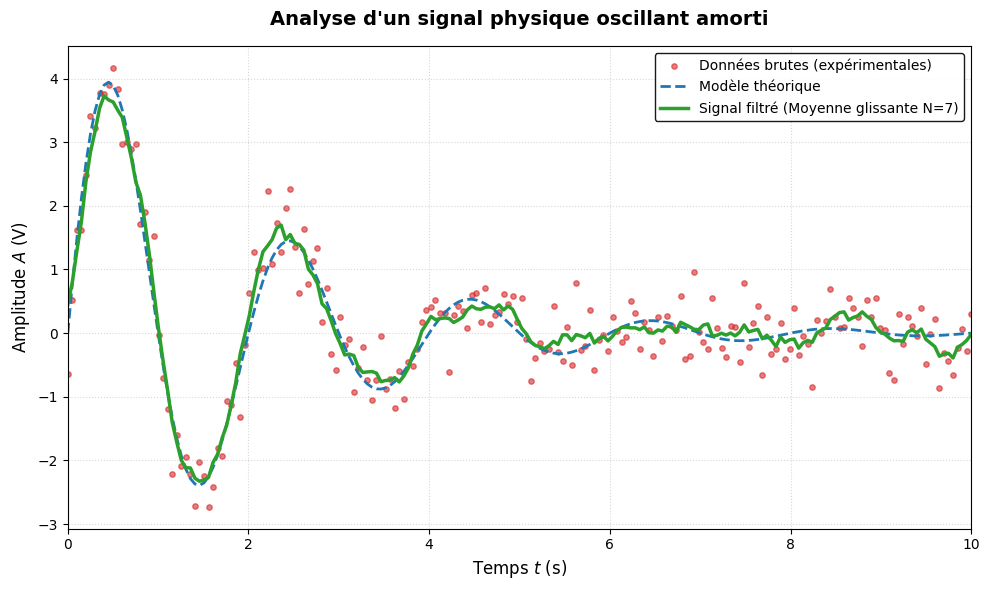

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Génération de données expérimentales simulées
temps = np.linspace(0, 10, 200)
signal_theorique = 5 * np.exp(-temps / 2) * np.sin(2 * np.pi * 0.5 * temps)
bruit = np.random.normal(0, 0.4, size=temps.shape)
signal_experimentaux = signal_theorique + bruit

# 2. Traitement des données : Lissage par moyenne glissante
window_size = 7
filtre = np.ones(window_size) / window_size
signal_lisse = np.convolve(signal_experimentaux, filtre, mode='same')

# 3. Création du graphique scientifique
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Tracé des points expérimentaux bruts
ax.scatter(temps, signal_experimentaux, color='#d62728', alpha=0.6, s=15, label='Données brutes (expérimentales)')

# Tracé de la courbe théorique idéale
ax.plot(temps, signal_theorique, color='#1f77b4', linestyle='--', linewidth=2, label='Modèle théorique')

# Tracé du signal filtré/lissé
ax.plot(temps, signal_lisse, color='#2ca02c', linewidth=2.5, label=f'Signal filtré (Moyenne glissante N={window_size})')

# Personnalisation avancée des axes et labels
ax.set_title('Analyse d\'un signal physique oscillant amorti', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Temps $t$ (s)', fontsize=12)
ax.set_ylabel('Amplitude $A$ (V)', fontsize=12)

# Grille de lecture fine
ax.grid(True, which='both', linestyle=':', alpha=0.5)

# Légende et style des bordures
ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='inherit')
ax.set_xlim(0, 10)

# Affichage optimal
plt.tight_layout()
plt.show()

### 💾 Importation, Traitement des Incertitudes et Multi-Panneaux

Dans la pratique scientifique, les données sont souvent chargées depuis des fichiers externes, contiennent des incertitudes de mesure et nécessitent des représentations compartimentées pour analyser les résidus d'un modèle.

Nous allons :
* Générer et sauvegarder un fichier de données simulé (`donnees_mesurees.csv`) avec des valeurs manquantes (`NaN`) et des incertitudes.
* Importer ce fichier proprement en filtrant les `NaN`.
* Créer une figure double panneau (vertical) affichant les données ajustées avec leurs barres d'erreur en haut, et les résidus de l'ajustement en bas.

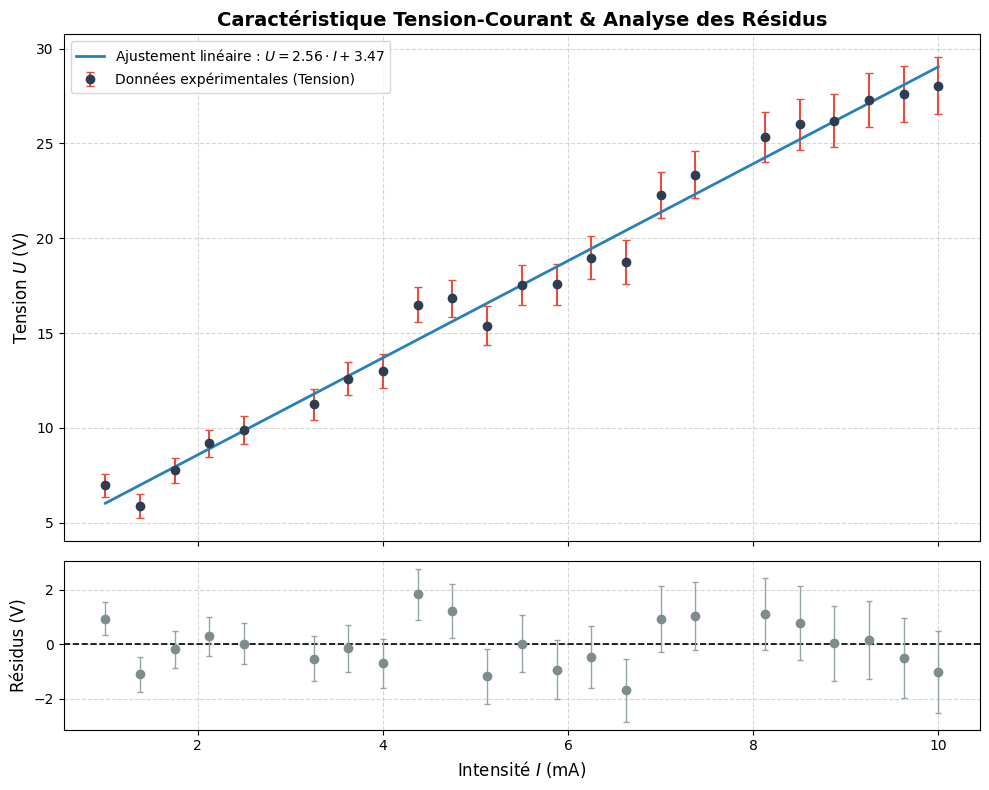

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulation et écriture d'un fichier CSV expérimental ---
# Nous générons des données avec une relation linéaire : y = a * x + b
x_raw = np.linspace(1, 10, 25)
incertitude_y = 0.5 + 0.1 * x_raw  # Incertitude variable (hétéroscédastique)
bruit_y = np.random.normal(0, incertitude_y)
y_raw = 2.5 * x_raw + 4.0 + bruit_y

# Introduction volontaire de quelques valeurs aberrantes / manquantes (NaN)
y_raw[5] = np.nan
y_raw[18] = np.nan

# Sauvegarde au format CSV
data_to_save = np.column_stack((x_raw, y_raw, incertitude_y))
header = "# x_val,y_val,y_err\n# Donnees experimentales de tension (V) en fonction de l'intensite (mA)"
np.savetxt("donnees_mesurees.csv", data_to_save, delimiter=",", header=header, comments="")

# --- 2. Importation et nettoyage des données ---
# Chargement en ignorant les lignes de commentaires et en gérant les NaN
data_loaded = np.genfromtxt("donnees_mesurees.csv", delimiter=",", comments="#")
mask_clean = ~np.isnan(data_loaded[:, 1])  # Masque pour exclure les NaN sur y

x_data = data_loaded[mask_clean, 0]
y_data = data_loaded[mask_clean, 1]
y_err = data_loaded[mask_clean, 2]

# --- 3. Modélisation / Régression linéaire simple (Fit) ---
pentes, covariance = np.polyfit(x_data, y_data, 1, cov=True)
a_fit, b_fit = pentes
y_modele = a_fit * x_data + b_fit
residus = y_data - y_modele

# --- 4. Tracé Multi-Panneau Professionnel (Subplots) ---
fig, (ax_main, ax_residus) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}, dpi=100
)

# Panneau Supérieur : Données, Barres d'erreur et Fit
ax_main.errorbar(
    x_data, y_data, yerr=y_err, fmt='o', color='#2c3e50',
    ecolor='#e74c3c', elinewidth=1.5, capsize=3, label='Données expérimentales (Tension)'
)
# Utilisation d'un échappement correct pour le symbole LaTeX \cdot
ax_main.plot(x_data, y_modele, color='#2980b9', linewidth=2, label=f'Ajustement linéaire : $U = {a_fit:.2f} \\cdot I + {b_fit:.2f}$')
ax_main.set_ylabel('Tension $U$ (V)', fontsize=12)
ax_main.set_title('Caractéristique Tension-Courant & Analyse des Résidus', fontsize=14, fontweight='bold')
ax_main.grid(True, linestyle='--', alpha=0.5)
ax_main.legend(loc='upper left', fontsize=10)

# Panneau Inférieur : Résidus de l'ajustement
ax_residus.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax_residus.errorbar(x_data, residus, yerr=y_err, fmt='o', color='#7f8c8d', ecolor='#95a5a6', elinewidth=1, capsize=2)
ax_residus.set_xlabel('Intensité $I$ (mA)', fontsize=12)
ax_residus.set_ylabel('Résidus (V)', fontsize=12)
ax_residus.grid(True, linestyle='--', alpha=0.5)

# Ajustement de l'espacement entre les graphiques
plt.tight_layout()
plt.show()

### 🗺️ Visualisation de Champs 2D : Cartes de Chaleur et Lignes de Contour

En physique (thermodynamique, électrostatique, mécanique des fluides), les données se présentent souvent sous la forme de grilles bidimensionnelles $f(x, y)$.

Nous allons :
1. Créer une grille 2D à l'aide de `np.meshgrid`.
2. Calculer le potentiel électrostatique créé par un dipôle (deux charges opposées).
3. Représenter ce potentiel avec une carte de chaleur colorée (`imshow`), ajouter des lignes équipotentielles (`contour`) et une barre d'échelle colorée (`colorbar`).

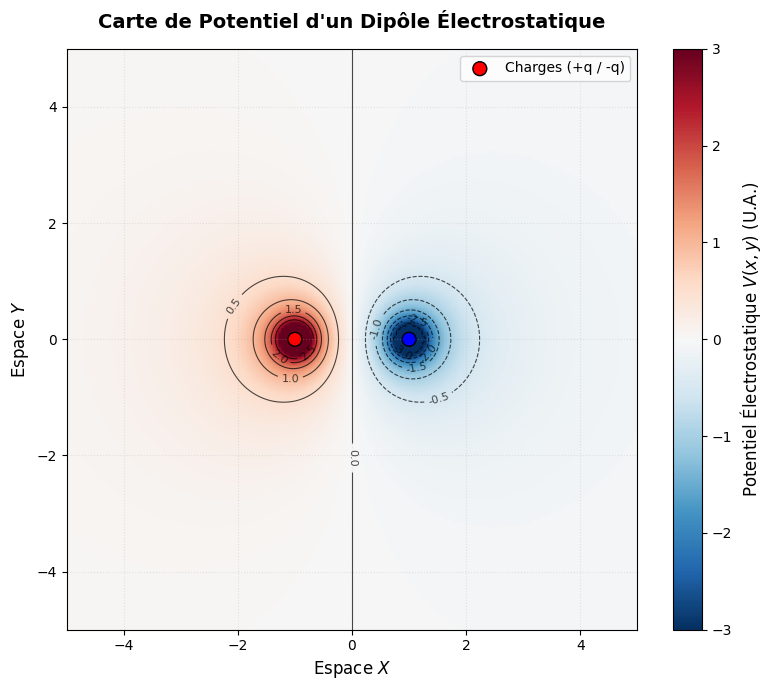

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Définition de la grille spatiale
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

# 2. Calcul du potentiel d'un dipôle électrostatique
# Charge +1 en (-1, 0) et Charge -1 en (1, 0)
d1 = np.sqrt((X + 1)**2 + Y**2) + 1e-9 # Éviter la division par zéro
d2 = np.sqrt((X - 1)**2 + Y**2) + 1e-9

Potentiel = 1.0 / d1 - 1.0 / d2

# Tronquer les valeurs extrêmes près des charges pour un meilleur rendu visuel
Potentiel = np.clip(Potentiel, -3, 3)

# 3. Création du tracé
fig, ax = plt.subplots(figsize=(8, 7), dpi=100)

# Tracé de la carte de chaleur 2D
im = ax.imshow(
    Potentiel, extent=[-5, 5, -5, 5], origin='lower',
    cmap='RdBu_r', aspect='auto'
)

# Ajout des lignes de contour (courbes équipotentielles)
contours = ax.contour(
    X, Y, Potentiel, levels=12, colors='black', linewidths=0.8, alpha=0.7
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Représentation de la position des charges
ax.scatter([-1, 1], [0, 0], color=['red', 'blue'], s=100, edgecolor='black', zorder=5, label='Charges (+q / -q)')

# Ajout d'une barre de couleur (Colorbar) explicative
cbar = fig.colorbar(im, ax=ax, pad=0.05)
cbar.set_label('Potentiel Électrostatique $V(x,y)$ (U.A.)', fontsize=12)

# Habillage final
ax.set_title('Carte de Potentiel d\'un Dipôle Électrostatique', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Espace $X$', fontsize=12)
ax.set_ylabel('Espace $Y$', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

## 🌀 Partie 3 : Modélisation et Simulation Physique (SciPy)

Dans cette dernière partie, nous abordons l'un des piliers du calcul scientifique : la **résolution d'équations différentielles** décrivant l'évolution temporelle de systèmes physiques dynamiques.

### ⏱️ Résolution Numérique d'Équations Différentielles Ordinaires (EDO)

La méthode moderne recommandée dans SciPy pour résoudre des EDO est l'utilisation de `scipy.integrate.solve_ivp` (qui remplace l'ancienne fonction historique `odeint`). Elle implémente des schémas d'intégration avancés (Runge-Kutta d'ordre 4-5 adaptatif RK45, méthodes implicites pour les équations raides, etc.).

Nous allons étudier un cas concret de physique : **le pendule simple amorti avec frottements et force d'excitation externe**, régi par l'équation non-linéaire du second ordre :

$$\frac{d^2\theta}{dt^2} + q \frac{d\theta}{dt} + \omega_0^2 \sin(\theta) = F_d \cos(\Omega t)$$

Pour la résoudre avec `solve_ivp`, nous devons la réécrire sous la forme d'un système de deux équations différentielles du premier ordre :
1. $\frac{d\theta}{dt} = \omega$
2. $\frac{d\omega}{dt} = -q \omega - \omega_0^2 \sin(\theta) + F_d \cos(\Omega t)$

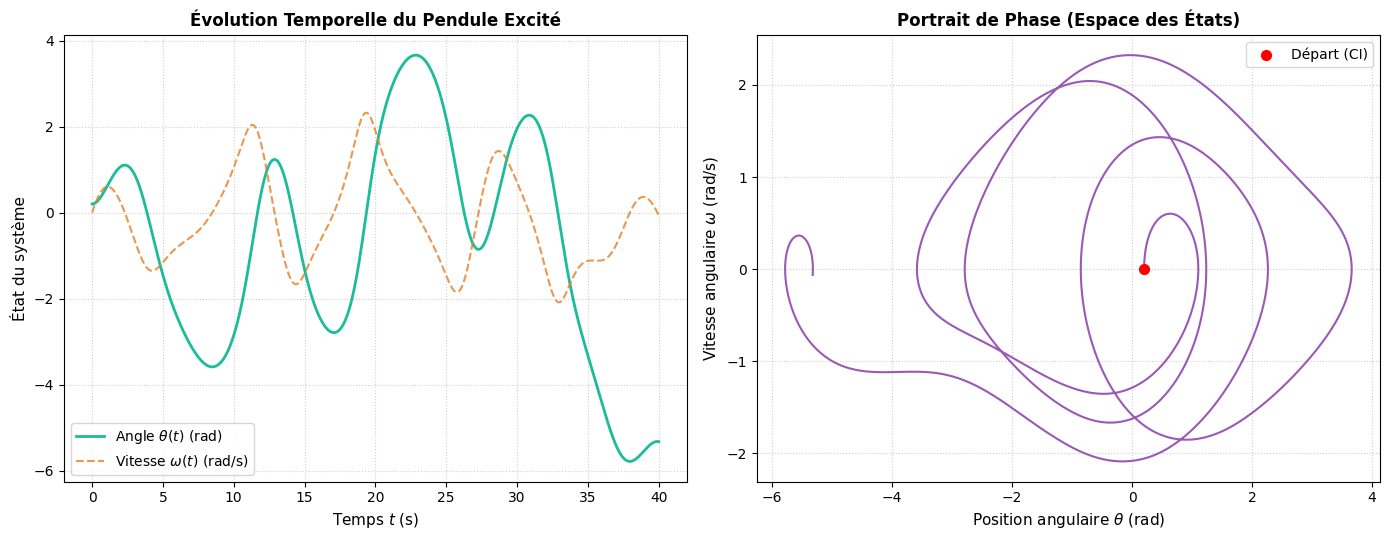

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Définition des paramètres physiques du système
omega_0 = 1.0  # Fréquence propre (rad/s)
q = 0.5        # Facteur d'amortissement (frottements)
F_d = 1.2      # Amplitude de la force d'excitation externe
Omega = 0.666  # Fréquence de l'excitation (régime chaotique possible selon les paramètres)

# 2. Définition de la fonction décrivant le système d'équations différentielles (dérivée temporelle)
def derivee_pendule(t, y, q, omega_0, F_d, Omega):
    theta, omega = y  # y contient l'état actuel [angle, vitesse angulaire]

    # Calcul des dérivées
    dtheta_dt = omega
    domega_dt = -q * omega - (omega_0**2) * np.sin(theta) + F_d * np.cos(Omega * t)

    return [dtheta_dt, domega_dt]

# 3. Conditions initiales et domaine d'intégration
theta_init = 0.2  # Angle initial (rad)
omega_init = 0.0  # Vitesse angulaire initiale (rad/s)
y_init = [theta_init, omega_init]

t_span = (0, 40)               # Intervalle d'intégration (de 0 à 40 secondes)
t_eval = np.linspace(0, 40, 1000) # Points de temps où l'on souhaite évaluer la solution

# 4. Résolution de l'EDO avec le solveur adaptatif Runge-Kutta 4-5 (RK45)
solution = solve_ivp(
    fun=derivee_pendule,
    t_span=t_span,
    y0=y_init,
    args=(q, omega_0, F_d, Omega),
    t_eval=t_eval,
    method='RK45'
)

# Extraction des résultats
temps_simu = solution.t
theta_simu = solution.y[0]
omega_simu = solution.y[1]

# 5. Visualisation des résultats de la simulation
fig, (ax_ang, ax_phase) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=100)

# Tracé temporel de la position et de la vitesse
ax_ang.plot(temps_simu, theta_simu, label=r'Angle $\theta(t)$ (rad)', color='#1abc9c', linewidth=2)
ax_ang.plot(temps_simu, omega_simu, label=r'Vitesse $\omega(t)$ (rad/s)', color='#e67e22', linestyle='--', alpha=0.8)
ax_ang.set_title('Évolution Temporelle du Pendule Excité', fontsize=12, fontweight='bold')
ax_ang.set_xlabel('Temps $t$ (s)', fontsize=11)
ax_ang.set_ylabel('État du système', fontsize=11)
ax_ang.grid(True, linestyle=':', alpha=0.6)
ax_ang.legend(loc='lower left')

# Tracé du portrait de phase (Espace des phases : vitesse vs position)
ax_phase.plot(theta_simu, omega_simu, color='#9b59b6', linewidth=1.5)
ax_phase.scatter(theta_init, omega_init, color='red', s=50, zorder=5, label='Départ (CI)')
ax_phase.set_title('Portrait de Phase (Espace des États)', fontsize=12, fontweight='bold')
ax_phase.set_xlabel(r'Position angulaire $\theta$ (rad)', fontsize=11)
ax_phase.set_ylabel(r'Vitesse angulaire $\omega$ (rad/s)', fontsize=11)
ax_phase.grid(True, linestyle=':', alpha=0.6)
ax_phase.legend()

plt.tight_layout()
plt.show()

### 🎯 Analyse Physique Avancée : Courbe de Résonance

Pour caractériser complètement notre système oscillant, nous cherchons à savoir comment son amplitude maximale en régime permanent (après atténuation des effets transitoires du début) dépend de la fréquence d'excitation $\Omega$.

Nous allons :
1. Définir une plage de fréquences $\Omega \in [0.1, 2.5]$.
2. Résoudre l'équation différentielle pour chaque fréquence sur un temps long (100 secondes) pour atteindre le régime permanent.
3. Extraire l'amplitude maximale de l'oscillation sur les 30 dernières secondes du signal.
4. Tracer la courbe de réponse en fréquence (courbe de résonance).

Calcul des simulations en cours pour chaque fréquence d'excitation...


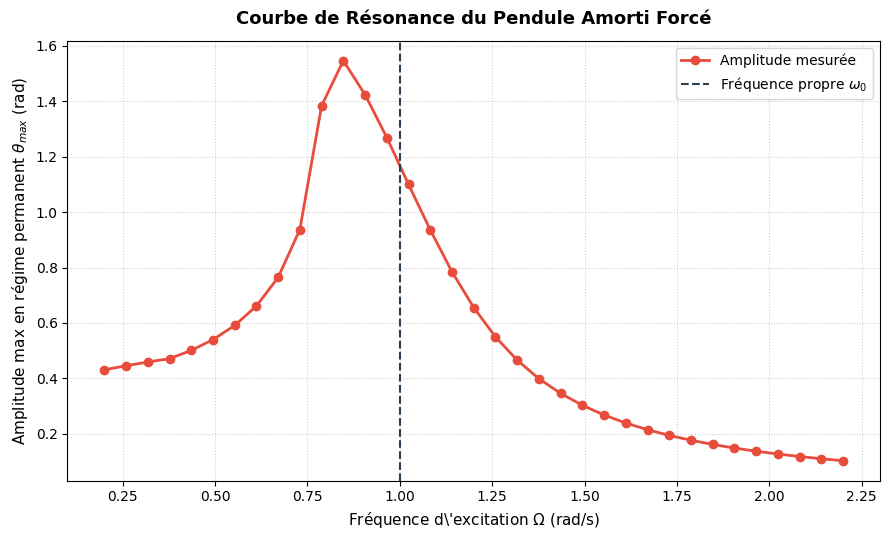

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Paramètres physiques fixes
omega_0 = 1.0
q = 0.3 # Amortissement plus faible pour bien voir la résonance
F_d = 0.4 # Faible excitation pour rester dans un régime proche de l'harmonique

def derivee_simple(t, y, q, omega_0, F_d, Omega):
    theta, omega = y
    return [omega, -q * omega - (omega_0**2) * np.sin(theta) + F_d * np.cos(Omega * t)]

# Plage de fréquences d'excitation
liste_Omega = np.linspace(0.2, 2.2, 35)
amplitudes = []

t_span_long = (0, 100)
t_eval_stable = np.linspace(70, 100, 300) # Évaluation uniquement sur la fin (régime établi)

print("Calcul des simulations en cours pour chaque fréquence d'excitation...")
for Om in liste_Omega:
    sol = solve_ivp(
        fun=derivee_simple,
        t_span=t_span_long,
        y0=[0.0, 0.0], # Départ au repos
        args=(q, omega_0, F_d, Om),
        t_eval=t_eval_stable,
        method='RK45'
    )
    # L'amplitude en régime établi est la valeur max absolue de l'angle atteint
    amp = np.max(np.abs(sol.y[0]))
    amplitudes.append(amp)

# Tracé de la courbe de résonance
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=100)
ax.plot(liste_Omega, amplitudes, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='Amplitude mesurée')

# Indication théorique de la fréquence propre
ax.axvline(x=omega_0, color='#2c3e50', linestyle='--', label=r'Fréquence propre $\omega_0$')

ax.set_title('Courbe de Résonance du Pendule Amorti Forcé', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel(r'Fréquence d\'excitation $\Omega$ (rad/s)', fontsize=11)
ax.set_ylabel(r'Amplitude max en régime permanent $\theta_{max}$ (rad)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# 🎓 Bilan de la Session de Formation

Félicitations pour avoir complété ce parcours intensif de calcul scientifique, de visualisation et de simulation en Python !

### 🔑 Ce qu'il faut retenir :

* **NumPy & Numba (Performance)** : Ne vous contentez pas d'éviter les boucles `for`. Pensez à l'alignement mémoire, exploitez le **Broadcasting** pour économiser de la RAM, manipulez les **Strides** pour des fenêtres glissantes virtuelles en temps constant $O(1)$, et compilez avec `@njit` (Numba) pour atteindre les performances du C/Fortran.
* **Matplotlib (Visualisation)** : Un graphique scientifique doit être auto-suffisant. Utilisez des barres d'erreur pour traduire l'incertitude de mesure, structurez vos analyses multi-panneaux avec `subplots` partagés, et représentez les données spatiales complexes à l'aide de tracés en contours et de cartes de chaleur (`imshow`).
* **SciPy (Simulation)** : Utilisez `solve_ivp` pour intégrer vos systèmes dynamiques. Pensez à toujours reformuler vos équations du second ordre (ou plus) en un système couplé d'équations du premier ordre, puis utilisez des solveurs adaptatifs (`RK45`, etc.) pour explorer les régimes transitoires, les espaces des phases et les comportements fréquentiels comme la résonance.

Vous disposez désormais d'un socle d'ingénierie numérique robuste et performant !

### 💾 Exportation du Rapport de Formation (HTML / PDF)

Exécutez la cellule ci-dessous pour compiler ce notebook complet en un document HTML autonome et le télécharger directement sur votre ordinateur.

*Note : Pour obtenir un fichier PDF, il vous suffira d'ouvrir le fichier HTML généré dans votre navigateur web et d'utiliser la fonction d'impression classique (`Ctrl+P` ou `Cmd+P`) en choisissant "Enregistrer au format PDF".*

In [7]:
import os
from google.colab import files

# 1. Sauvegarde automatique du notebook en cours d'utilisation dans l'environnement de Colab
# (Dans Colab, le notebook actuel se trouve généralement dans le répertoire parent ou accessible via l'API)
# Nous listons et convertissons le fichier .ipynb présent dans l'espace de stockage de la session

import glob
notebooks = glob.glob("/content/*.ipynb") + glob.glob("*.ipynb")

if not notebooks:
    # Si le notebook n'est pas détecté directement dans le répertoire de travail,
    # nous pouvons tenter de le cibler via le chemin par défaut de Colab
    print("Aucun fichier de notebook trouvé directement dans /content. Tentative de recherche globale...")
    os.system("cp /content/drive/MyDrive/Colab\ Notebooks/*.ipynb . 2>/dev/null")
    notebooks = glob.glob("*.ipynb")

if notebooks:
    target_notebook = notebooks[0]
    print(f"Notebook identifié pour l'exportation : {target_notebook}")

    # 2. Utilisation de nbconvert pour transformer le notebook en fichier HTML
    print("Conversion en cours... (génération du fichier HTML de votre rapport)")
    os.system(f"jupyter nbconvert --to html '{target_notebook}'")

    html_file = target_notebook.replace('.ipynb', '.html')

    if os.path.exists(html_file):
        print(f"🎉 Rapport HTML généré avec succès : {html_file}")
        print("Lancement du téléchargement...")
        files.download(html_file)
    else:
        print("Erreur lors de la conversion du fichier.")
else:
    print("❌ Impossible de localiser le fichier .ipynb actif dans l'environnement de runtime.")
    print("Conseil : Allez dans le menu 'Fichier' > 'Enregistrer' puis téléchargez manuellement via 'Fichier' > 'Télécharger .ipynb'.")

Aucun fichier de notebook trouvé directement dans /content. Tentative de recherche globale...
❌ Impossible de localiser le fichier .ipynb actif dans l'environnement de runtime.
Conseil : Allez dans le menu 'Fichier' > 'Enregistrer' puis téléchargez manuellement via 'Fichier' > 'Télécharger .ipynb'.


<>:15: SyntaxWarning: invalid escape sequence '\ '
<>:15: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2945/1796285568.py:15: SyntaxWarning: invalid escape sequence '\ '
  os.system("cp /content/drive/MyDrive/Colab\ Notebooks/*.ipynb . 2>/dev/null")
